## 1. Setup 

In [298]:
%pip -q install numpy pandas matplotlib scikit-learn seaborn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [299]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns",None)
sns.set_style("whitegrid")

## 2. DATA LOADING

In [300]:
df=pd.read_csv("loan.csv")

In [301]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [302]:
df.shape

(614, 13)

In [303]:
df.columns=[col.lower() for col in df.columns]

In [304]:
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='str')

In [305]:
df.nunique()

loan_id              614
gender                 2
married                2
dependents             4
education              2
self_employed          2
applicantincome      505
coapplicantincome    287
loanamount           203
loan_amount_term      10
credit_history         2
property_area          3
loan_status            2
dtype: int64

In [306]:
df=df.drop(columns=["loan_id"])

In [307]:
target_col="loan_status"

In [308]:
df[target_col]=df[target_col].map({"Y":1,"N":0})

In [309]:
df.sample(2)

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
337,Male,Yes,2,Graduate,Yes,2500,4600.0,176.0,360.0,1.0,Rural,1
517,Male,Yes,NaN,Not Graduate,No,3074,1800.0,123.0,360.0,0.0,Semiurban,0


In [310]:
x=df.drop(columns=target_col)
y=df[target_col]

In [311]:
X_train,X_test, y_train,y_test=train_test_split(
    x,
    y,
    random_state=42,
    stratify=y,
    test_size=0.2
)

In [312]:
X_train.shape

(491, 11)

In [313]:
X_train_processed=X_train.copy()
X_test_processed=X_test.copy()



**Identifying numerical and categorical data**

In [314]:
nums_cols= X_train_processed.select_dtypes(include=[np.number]).columns.tolist()
cat_cols= X_train_processed.select_dtypes(include=["object"]).columns.tolist()


C:\Users\kaush\AppData\Local\Temp\ipykernel_28288\2685578359.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols= X_train_processed.select_dtypes(include=["object"]).columns.tolist()


In [315]:
nums_cols
cat_cols

['gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'property_area']

In [316]:
X_train.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban
239,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban
448,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural
471,Male,Yes,1,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural
273,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban


### Handling missing values

In [317]:
X_train_processed[nums_cols].isna().sum()

applicantincome       0
coapplicantincome     0
loanamount           20
loan_amount_term     12
credit_history       43
dtype: int64

In [318]:
if nums_cols:
    num_imputer=SimpleImputer(strategy="median")
    X_train_processed[nums_cols]=num_imputer.fit_transform(X_train_processed[nums_cols])
    X_test_processed[nums_cols]=num_imputer.transform(X_test_processed[nums_cols])
    
    
if cat_cols:
    cat_imputer=SimpleImputer(strategy="most_frequent")
    X_train_processed[cat_cols]=cat_imputer.fit_transform(X_train_processed[cat_cols])
    X_test_processed[cat_cols]=cat_imputer.fit_transform(X_test_processed[cat_cols])
    
    

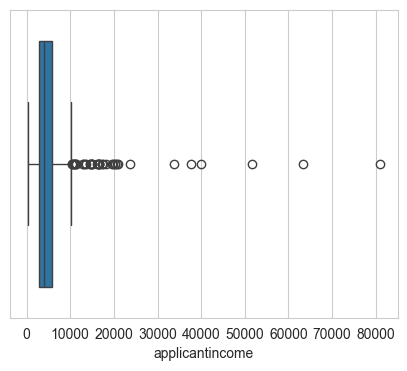

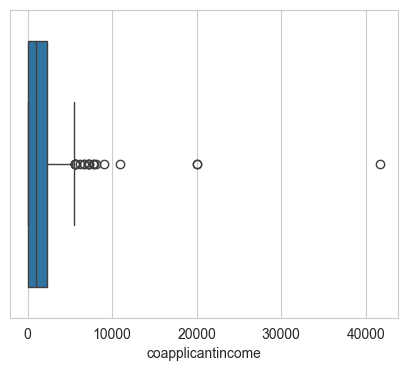

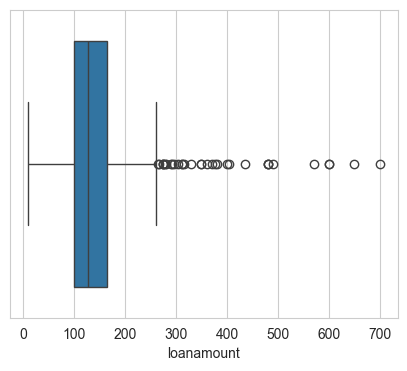

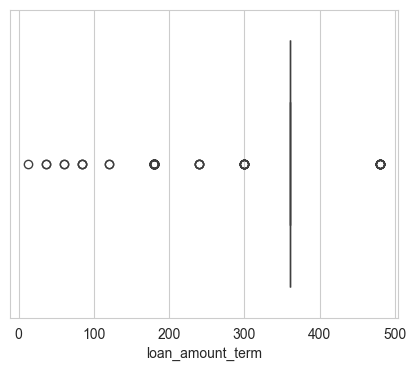

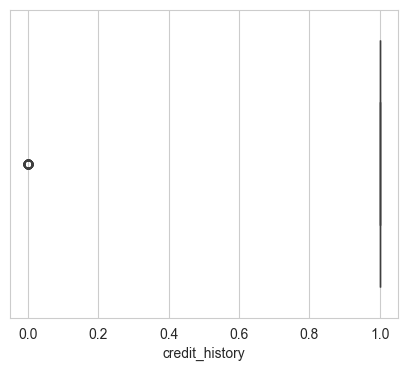

In [319]:
for col in nums_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=X_train_processed[col])
    plt.show()

In [320]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    return lower_bound, upper_bound


def compute_train_bounds(df, cols):
    bounds = {}
    
    for col in cols:
        lower, upper = iqr_bounds(df[col])
        bounds[col] = (lower, upper)  # tuple, not set
        
    return bounds


def cap_outliers_with_bounds(df, bounds):
    df_capped = df.copy()
    
    for col, (lower, upper) in bounds.items():
        df_capped[col] = np.where(df_capped[col] < lower,lower,df_capped[col]
        )
        
        df_capped[col] = np.where(
            df_capped[col] > upper,
            upper,
            df_capped[col]
        )
    
    return df_capped

In [321]:
y_train.shape

(491,)

In [322]:
print(type(train_bound))

<class 'dict'>


In [323]:
outliers_cols=["applicantincome","coapplicantincome","loanamount"]
train_bound=compute_train_bounds(X_train_processed,outliers_cols)


In [324]:
X_train_processed[outliers_cols]=cap_outliers_with_bounds(X_train_processed[outliers_cols],train_bound)
X_test_processed[outliers_cols]=cap_outliers_with_bounds(X_test_processed[outliers_cols],train_bound)


In [325]:
X_train_processed[cat_cols].isnull().sum()

gender           0
married          0
dependents       0
education        0
self_employed    0
property_area    0
dtype: int64

In [326]:
le_cat=["gender","married","education","self_employed"]
le=LabelEncoder()



In [327]:
label={}
for col in le_cat:
    le=LabelEncoder()
    le.fit(X_train_processed[col])
    label[col]=le
    X_train_processed[col]=le.transform(X_train_processed[col])
    X_test_processed[col]=le.transform(X_test_processed[col])
    
    

In [328]:
X_train_processed.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,1,0,0,0,0,3254.0,0.0,50.0,360.0,1.0,Urban
239,1,1,1,0,0,3315.0,0.0,96.0,360.0,1.0,Semiurban
448,1,1,2,0,0,3340.0,1710.0,150.0,360.0,0.0,Rural
471,1,1,1,1,0,2653.0,1500.0,113.0,180.0,0.0,Rural
273,1,1,0,0,0,2620.0,2223.0,150.0,360.0,1.0,Semiurban


In [329]:
ohe_cat=["property_area"]
ohe=OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)

In [330]:
ohe.fit(X_train_processed[ohe_cat])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infre

In [331]:
train_ohe=ohe.transform(X_train_processed[ohe_cat])
test_ohe=ohe.transform(X_test_processed[ohe_cat])


In [332]:
ohe_cols=ohe.get_feature_names_out(ohe_cat)
print(ohe_cols)

['property_area_Semiurban' 'property_area_Urban']


In [333]:
train_ohe=pd.DataFrame(train_ohe,columns=ohe_cols,index=X_train_processed.index )
test_ohe=pd.DataFrame(test_ohe,columns=ohe_cols,index=X_test_processed.index )


In [334]:
train_ohe.shape
X_train_processed.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,1,0,0,0,0,3254.0,0.0,50.0,360.0,1.0,Urban
239,1,1,1,0,0,3315.0,0.0,96.0,360.0,1.0,Semiurban
448,1,1,2,0,0,3340.0,1710.0,150.0,360.0,0.0,Rural
471,1,1,1,1,0,2653.0,1500.0,113.0,180.0,0.0,Rural
273,1,1,0,0,0,2620.0,2223.0,150.0,360.0,1.0,Semiurban


In [335]:
X_train_processed=pd.concat([X_train_processed,train_ohe],axis=1)
X_test_processed=pd.concat([X_test_processed,test_ohe],axis=1)

In [336]:
X_train_processed.shape

(491, 13)

In [337]:
X_train_processed=X_train_processed.drop(columns=["property_area"])

In [338]:
y_train.value_counts()

loan_status
1    337
0    154
Name: count, dtype: int64

In [339]:
y_test.value_counts()

loan_status
1    85
0    38
Name: count, dtype: int64

In [340]:
smote=SMOTE(random_state=12)




In [341]:
print(type(y_train))

<class 'pandas.Series'>


In [342]:
print(X_train_processed[X_train_processed["dependents"]=="3+"].sum())

gender                                                                    37
married                                                                   34
dependents                 3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+3+...
education                                                                 14
self_employed                                                              5
applicantincome                                                     200560.0
coapplicantincome                                                    45550.0
loanamount                                                            6061.0
loan_amount_term                                                     12480.0
credit_history                                                          31.0
property_area_Semiurban                                                 15.0
property_area_Urban                                                     10.0
dtype: object


In [343]:
X_train_processed["dependents"]=X_train_processed["dependents"].replace("3+",3)
X_test_processed["dependents"]=X_test_processed["dependents"].replace("3+",3)


In [344]:
print(type(X_train_processed["dependents"]))

<class 'pandas.Series'>


In [345]:
X_train_processed["dependents"]=X_train_processed["dependents"].astype("int64")

In [346]:
print(X_train_processed.dtypes)

gender                       int64
married                      int64
dependents                   int64
education                    int64
self_employed                int64
applicantincome            float64
coapplicantincome          float64
loanamount                 float64
loan_amount_term           float64
credit_history             float64
property_area_Semiurban    float64
property_area_Urban        float64
dtype: object


In [347]:
X_train_processed.shape

(491, 12)

In [348]:
y_train.shape

(491,)

In [349]:
X_train_processed,y_train=smote.fit_resample(X_train_processed,y_train)

In [351]:
y_test.value_counts()

loan_status
1    85
0    38
Name: count, dtype: int64

In [352]:
scaler=StandardScaler()

In [354]:
X_train.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area'],
      dtype='str')

In [355]:
X_train.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban
239,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban
448,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural
471,Male,Yes,1,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural
273,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban


In [356]:
scale_cols=["applicantincome","coapplicantincome","loanamount","loan_amount_term"]

In [357]:
scaler.fit(X_train_processed[scale_cols])

StandardScaler()

In [358]:
X_train_processed[scale_cols]=scaler.transform(X_train_processed[scale_cols])
X_test_processed[scale_cols]=scaler.transform(X_test_processed[scale_cols])


In [360]:
X_train_processed.describe()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area_Semiurban,property_area_Urban
count,674.000000,674.000000,674.000000,674.000000,674.000000,6.740000e+02,6.740000e+02,6.740000e+02,6.740000e+02,674.000000,674.000000,674.000000
mean,0.795252,0.596439,0.670623,0.191395,0.103858,-1.153051e-16,-9.487959e-17,-4.401359e-16,-3.742473e-16,0.777519,0.339108,0.345616
std,0.403817,0.490976,0.933827,0.393691,0.305302,1.000743e+00,1.000743e+00,1.000743e+00,1.000743e+00,0.389090,0.458167,0.453419
min,0.000000,0.000000,0.000000,0.000000,0.000000,-1.793510e+00,-8.345168e-01,-2.348444e+00,-5.327587e+00,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,-7.027017e-01,-8.345168e-01,-6.584916e-01,2.836848e-01,0.701777,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,-3.249281e-01,-2.991679e-01,-1.870559e-01,2.836848e-01,1.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,5.035429e-01,5.499268e-01,4.985945e-01,2.836848e-01,1.000000,1.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,2.233456e+00,2.607012e+00,2.242235e+00,2.218606e+00,1.000000,1.000000,1.000000


In [ ]:
target='loan_status'

In [363]:
train_df_final=X_train_processed.copy()
train_df_final[target_col]=y_train.values




test_df_final=X_test_processed.copy()
test_df_final[target_col]=y_test.values


train_df_final=train_df_final.round(3)
test_df_final=test_df_final.round(3)


train_df_final.to_csv("Loan_train_prepared_data.csv")
test_df_final.to_csv("Loan_test_prepared_data.csv")


